# Amortized collective inference with NPE

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import WF

import matplotlib as mpl
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.simplefilter('ignore', Warning)


generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns
TESTS_DIR = Path('tests')
TESTS_DIR.mkdir(exist_ok=True)
NPSE_RESULTS_DIR = TESTS_DIR

# Default behavior: use saved posterior samples when they exist.
# Set FORCE_RECOMPUTE_SAMPLES = True in a notebook cell if you explicitly want to rerun sampling.
REUSE_SAVED_SAMPLES = True
FORCE_RECOMPUTE_SAMPLES = False

SAMPLE_METHOD_PREFIXES = {
    'npse': 'npse',
    'collective': 'collective',
    'collective_posterior': 'collective',
    'npe_pie': 'npe_pie',
}


def normalize_sample_method(method):
    method_key = method.lower().replace('+', '_').replace(' ', '_').replace('-', '_')
    if method_key not in SAMPLE_METHOD_PREFIXES:
        raise ValueError(f'Unknown sample method {method}. Expected one of {sorted(SAMPLE_METHOD_PREFIXES)}')
    return SAMPLE_METHOD_PREFIXES[method_key]


def method_sample_path(method, line=None, cycle=False):
    sample_prefix = f"{'cycle_' if cycle else ''}samples_{normalize_sample_method(method)}"
    sample_suffix = 'empirical' if line is None else line
    return TESTS_DIR / f'{sample_prefix}_{sample_suffix}.pt'


def method_cycle_observation_path(method, line=None):
    sample_suffix = 'empirical' if line is None else line
    return TESTS_DIR / f'cycle_observations_{normalize_sample_method(method)}_{sample_suffix}.pt'


def should_load_saved_samples(path):
    return REUSE_SAVED_SAMPLES and not FORCE_RECOMPUTE_SAMPLES and Path(path).exists()


def load_method_samples(method, line=None, cycle=False):
    path = method_sample_path(method, line=line, cycle=cycle)
    if path.exists():
        return torch.load(path)

    aggregate_path = method_sample_path(method, cycle=cycle)
    if line is not None and aggregate_path.exists():
        aggregate_samples = torch.load(aggregate_path)
        if isinstance(aggregate_samples, dict) and line in aggregate_samples:
            return aggregate_samples[line]

    raise FileNotFoundError(f'Missing {path}. Rerun the corresponding sampling/inference-cycle cell first.')


def try_load_method_samples(method, line=None, cycle=False):
    if not REUSE_SAVED_SAMPLES or FORCE_RECOMPUTE_SAMPLES:
        return None
    try:
        return load_method_samples(method, line=line, cycle=cycle)
    except FileNotFoundError:
        return None


def load_npse_samples(line=None, cycle=False):
    return load_method_samples('npse', line=line, cycle=cycle)


def load_collective_samples(line=None, cycle=False):
    return load_method_samples('collective', line=line, cycle=cycle)


def load_npe_pie_samples(line=None, cycle=False):
    return load_method_samples('npe_pie', line=line, cycle=cycle)

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize


# Get Collective Posterior
## $P(\theta|X_{1},...X_{n}) = $ ${{P(\theta)}^{1-n}\Pi_{i}[P(\theta|X_{i})]} \over {\int{{P(\zeta)}^{1-n}}\Pi_{i}[P(\zeta|X_{i})]d\zeta}$

In [2]:
# Prior doesn't have to be identical to network's prior (here it is)
prior_min = np.log10(np.array([1e-2,1e-7,1e-8]))
prior_max = np.log10(np.array([1,1e-2,1e-2]))
prior = utils.BoxUniform(low=torch.tensor(prior_min), 
                         high=torch.tensor(prior_max))
posterior_chuong = pickle.load(open(f'posteriors/posterior_WF_30000_20.pkl', 'rb'))

collective_posteriors = {}

lines = ['wt','ltr','ars','all']
for line in lines:
    amortized_posterior = posterior_chuong
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0) # observations
    Xs = torch.tensor(np.array(Xs), dtype=torch.float32)
    log_C = 1
    op = CollectivePosterior(prior, Xs, amortized_posterior,log_C, epsilon=-100.0)
    collective_posteriors[line] = op # to use throughout the notebook

    sample_path = method_sample_path('collective', line=line)
    saved_samples = try_load_method_samples('collective', line=line)
    if saved_samples is not None:
        op.samples = saved_samples
        print(f'Loaded collective samples for {line}')
    else:
        op.epsilon = op.estimate_epsilon(Xs)[0]
        op.samples = op.adaptive_sir()
        torch.save(op.samples.detach().cpu(), sample_path)
        print(f'Saved collective samples for {line} to {sample_path}')

torch.save(
    {line: collective_posteriors[line].samples.detach().cpu() for line in lines},
    method_sample_path('collective'),
)

rep_colors = {'wt':"black", 'ltr':"#6699cc", 'ars': "#e26d5c", 'all':"#DEBD52"}
label_dict = {'wt': 'A', 'ltr': 'B', 'ars': 'C', 'all': 'D'}


Loaded collective samples for wt
Loaded collective samples for ltr
Loaded collective samples for ars
Loaded collective samples for all


# Collective Posterior Validation

## Predictive Checks - Simulate Collective Posterior MAP and compare to empirical observations

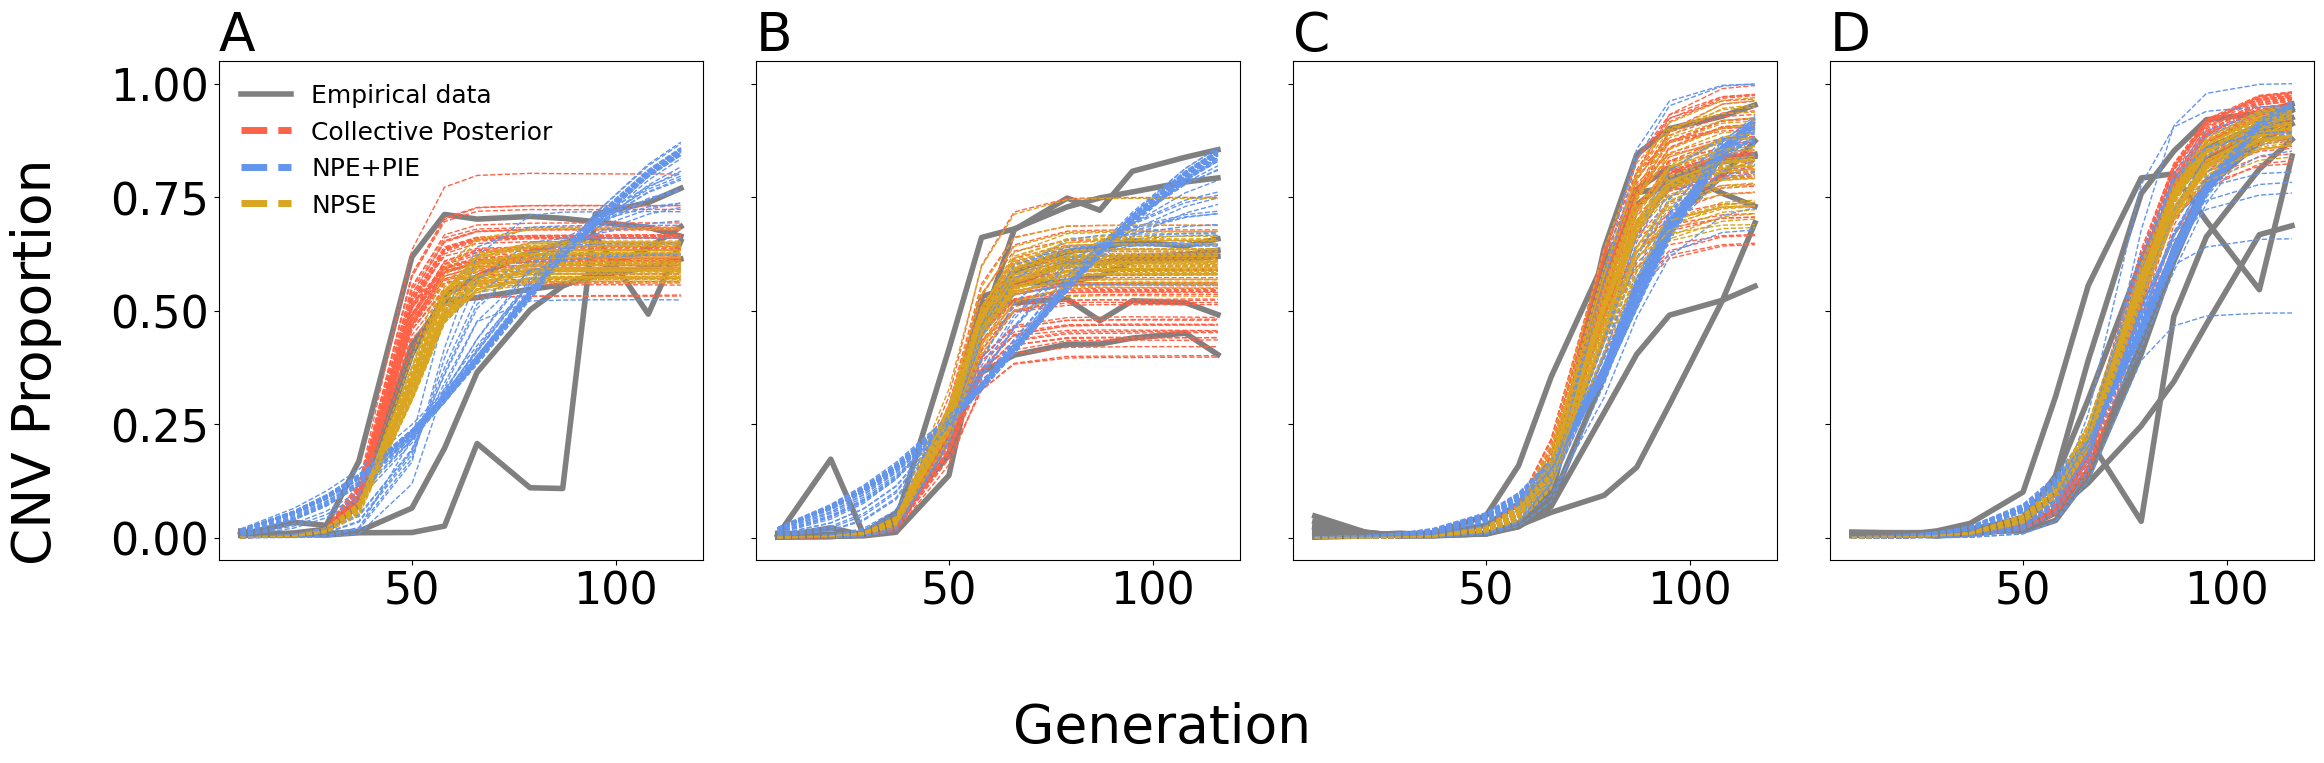

In [3]:
posterior_iid = pickle.load(open('posteriors/posterior_iid_WF_30000_20.pkl', 'rb'))
change_font(32)

n = 50
lw = n/50

def plot_collective_ppc(ax, line, color):
    cp = collective_posteriors[line]
    samples = cp.samples[:n]
    Xs = collective_posteriors[line].Xs
    for i in range(len(Xs)):
        ax.plot(generation.astype('int'),Xs[i], color='grey', lw=4, label='Empirical data' if i==0 and line=='wt' else '')
    for j in range(len(samples)):
        ax.plot(generation.astype('int'), WF(parameters=samples[j]), ls='--', color=color, lw=lw, label='Collective Posterior' if j==0 and line=='wt' else '')
    
fig, ax = plt.subplots(1,4, figsize=(24,8), sharex=True, sharey=True, tight_layout=True)
fig.supylabel('CNV Proportion')
fig.supxlabel('Generation')

for k in range(len(lines)):
    # i = (k%2, k//2)
    line = lines[k]
    plot_collective_ppc(ax[k], line, 'tomato')
    ax[k].set_title(label_dict[line], loc = 'left')

for k in range(len(lines)):
    # i = k%2, k//2
    line = lines[k]
    full_X = torch.empty(10,12)
    X = collective_posteriors[line].Xs
    full_X[:len(X)] = X
    full_X[len(X):] = torch.nan
    try:
        samples = load_npe_pie_samples(line)[:n]
    except FileNotFoundError:
        samples = posterior_iid.set_default_x(full_X).sample((n,))
    samples_npse = load_npse_samples(line)[:n]
    for j in range(len(samples)):
        ax[k].plot(generation.astype('int'), WF(parameters=samples[j]), color='cornflowerblue', ls='--', lw=lw, label='NPE+PIE' if j==0 and k==0 else '')
        ax[k].plot(generation.astype('int'), WF(parameters=samples_npse[j]), color='goldenrod', ls='--', lw=lw, label='NPSE' if j==0 and k==0 else '')
leg = ax[0].legend(fontsize=18, markerscale=80, frameon=False)
leg.get_lines()[1].set_linewidth(5)
leg.get_lines()[2].set_linewidth(5)
leg.get_lines()[3].set_linewidth(5)


wt tensor([-0.5462, -5.5280, -5.2441]) tensor([-0.7035, -4.7434, -4.2365])
ltr tensor([-0.5923, -5.8707, -5.4276]) tensor([-0.6846, -5.1185, -4.6243])
ars tensor([-0.7617, -6.0662, -5.9859]) tensor([-0.7955, -5.8013, -5.6194])
all tensor([-0.8310, -5.4601, -5.7594]) tensor([-0.8877, -4.9123, -5.0637])


Text(0, 0.5, '$log_{10}(s)$')

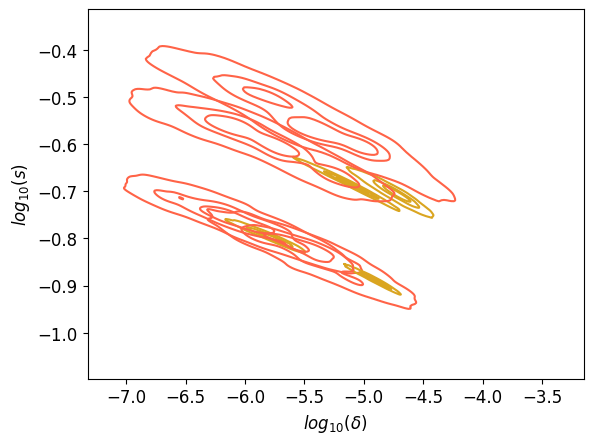

In [4]:
from seaborn import kdeplot
change_font(12)
# fig, ax = plt.subplots(1,3)
for line in lines:
    samples_npse = load_npse_samples(line)
    kdeplot(x=samples_npse[:,1], y=samples_npse[:,0], color='goldenrod', lw=0.5, levels=4)
    kdeplot(x=collective_posteriors[line].samples[:,1], y=collective_posteriors[line].samples[:,0], color='tomato', lw=0.5, levels=4)
    print(line, collective_posteriors[line].samples.mean(0), samples_npse.mean(0))

plt.xlabel('$log_{10}(\\delta)$')
plt.ylabel('$log_{10}(s)$')


Loaded collective cycle samples for wt
Loaded NPE+PIE samples for wt
Loaded NPE+PIE cycle samples for wt
Loaded collective cycle samples for ltr
Loaded NPE+PIE samples for ltr
Loaded NPE+PIE cycle samples for ltr
Loaded collective cycle samples for ars
Loaded NPE+PIE samples for ars
Loaded NPE+PIE cycle samples for ars
Loaded collective cycle samples for all
Loaded NPE+PIE samples for all
Loaded NPE+PIE cycle samples for all


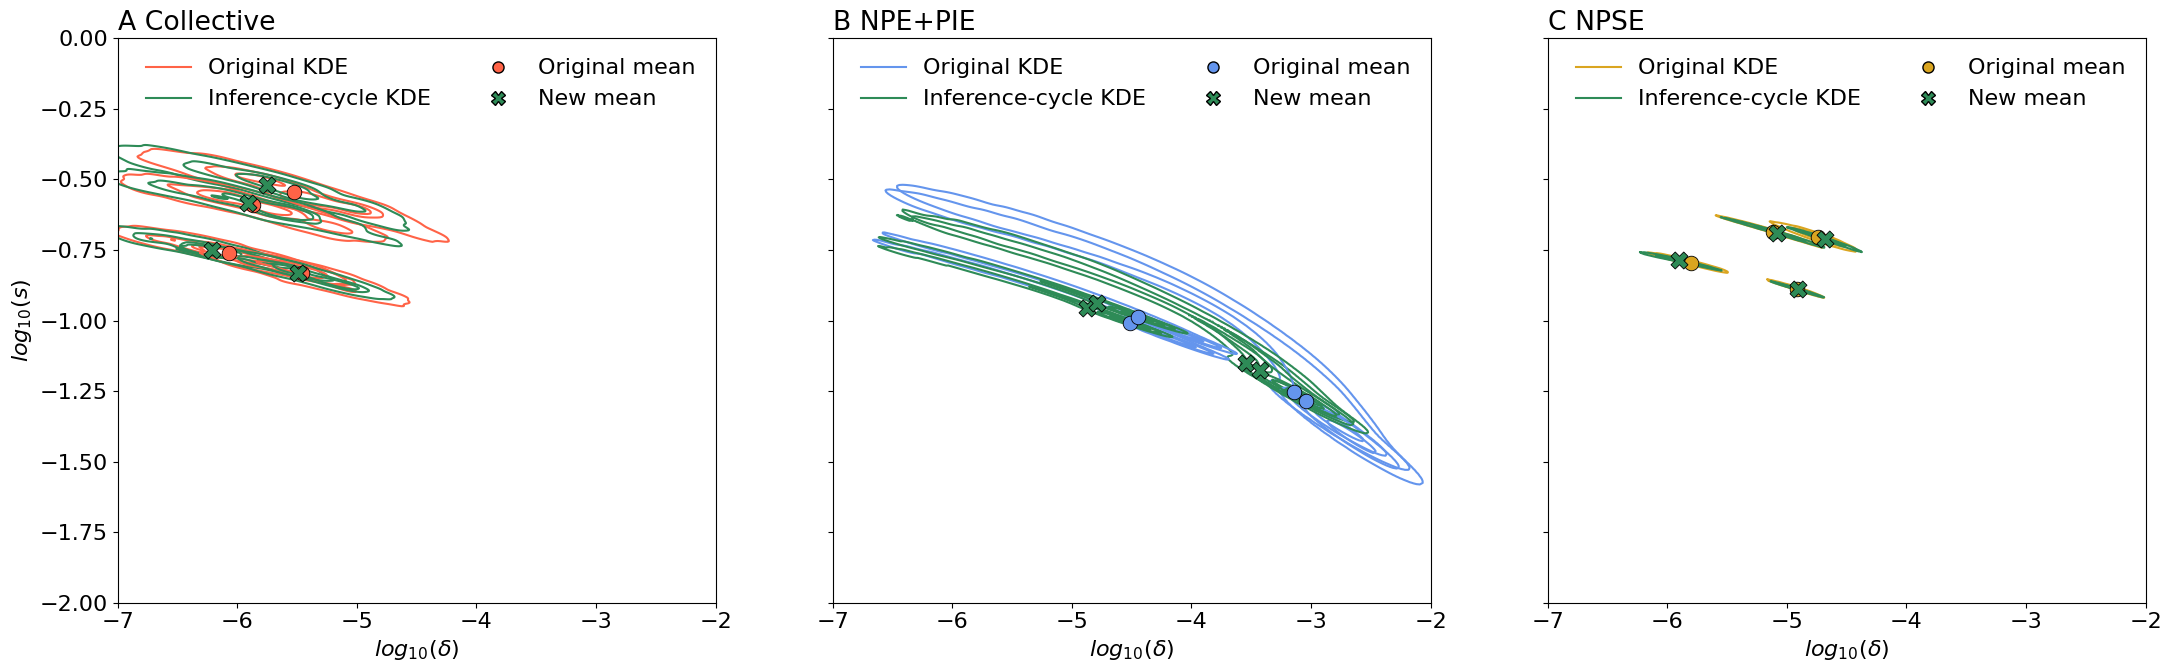

,line,collective_original_s_mean,collective_original_delta_mean,collective_new_s_mean,collective_new_delta_mean,npe_pie_original_s_mean,npe_pie_original_delta_mean,npe_pie_new_s_mean,npe_pie_new_delta_mean,npse_original_s_mean,npse_original_delta_mean,npse_new_s_mean,npse_new_delta_mean
0,wt,-0.546159,-5.527973,-0.518033,-5.748648,-1.254186,-3.145593,-1.150771,-3.546223,-0.703549,-4.743391,-0.711732,-4.679722
1,ltr,-0.592344,-5.870728,-0.584628,-5.910775,-1.283900,-3.038665,-1.176175,-3.426838,-0.684570,-5.118544,-0.689296,-5.081043
2,ars,-0.761680,-6.066241,-0.751571,-6.210442,-1.007512,-4.515487,-0.955727,-4.877476,-0.795504,-5.801318,-0.787104,-5.905016
3,all,-0.830965,-5.460055,-0.831247,-5.490711,-0.987177,-4.442953,-0.936529,-4.791803,-0.887694,-4.912336,-0.889314,-4.910100


In [5]:
# Inference-cycle KDE comparison: Collective Posterior vs NPE+PIE vs NPSE
change_font(16)

if 'TESTS_DIR' not in globals():
    TESTS_DIR = Path('tests')
    TESTS_DIR.mkdir(exist_ok=True)
if 'posterior_iid' not in globals():
    posterior_iid = pickle.load(open('posteriors/posterior_iid_WF_30000_20.pkl', 'rb'))

if hasattr(prior, 'base_dist') and hasattr(prior.base_dist, 'low'):
    prior_low = prior.base_dist.low.cpu()
    prior_high = prior.base_dist.high.cpu()
else:
    prior_low = prior.low.cpu()
    prior_high = prior.high.cpu()


def pad_replicates(Xs, max_reps=10):
    full_X = torch.full((max_reps, Xs.shape[1]), torch.nan, dtype=torch.float32)
    full_X[:len(Xs)] = Xs.to(torch.float32)
    return full_X


def cpu_copy(samples):
    return torch.as_tensor(samples).detach().cpu()


def maybe_load_cycle_observations(method, line, theta_mean):
    path = method_cycle_observation_path(method, line=line)
    if should_load_saved_samples(path):
        return torch.load(path)

    x_cycle = torch.stack([WF(parameters=theta_mean).to(torch.float32) for _ in range(10)])
    torch.save(cpu_copy(x_cycle), path)
    return x_cycle


cycle_summary = []
cycle_results = {}
collective_cycle_observations = {}
npe_pie_cycle_observations = {}
collective_original_color = 'tomato'
collective_cycle_color = 'seagreen'
iid_original_color = 'cornflowerblue'
iid_cycle_color = 'seagreen'
npse_original_color = 'goldenrod'
npse_cycle_color = 'seagreen'

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True, sharey=True, tight_layout=True)
ax_collective, ax_iid, ax_npse = axes

for line in lines:
    cp_original = collective_posteriors[line]
    x_o = cp_original.Xs
    cp_original_mean = cp_original.samples.mean(0)

    torch.save(cpu_copy(cp_original.samples), method_sample_path('collective', line=line))

    collective_cycle_sample_path = method_sample_path('collective', line=line, cycle=True)
    saved_cp_cycle_samples = try_load_method_samples('collective', line=line, cycle=True)
    if saved_cp_cycle_samples is not None:
        cp_cycle_samples = saved_cp_cycle_samples
        x_cycle_cp = maybe_load_cycle_observations('collective', line, cp_original_mean)
        print(f'Loaded collective cycle samples for {line}')
    else:
        x_cycle_cp = torch.stack([WF(parameters=cp_original_mean).to(torch.float32) for _ in range(10)])
        cp_cycle = CollectivePosterior(prior, x_cycle_cp, posterior_chuong, 1, epsilon=-100.0)
        cp_cycle.epsilon = cp_cycle.estimate_epsilon(x_cycle_cp)[0]
        cp_cycle_samples = cp_cycle.adaptive_sir()
        torch.save(cpu_copy(cp_cycle_samples), collective_cycle_sample_path)
        torch.save(cpu_copy(x_cycle_cp), method_cycle_observation_path('collective', line=line))
        print(f'Saved collective cycle samples for {line} to {collective_cycle_sample_path}')

    cp_cycle_mean = cp_cycle_samples.mean(0)
    collective_cycle_observations[line] = cpu_copy(x_cycle_cp)

    sns.kdeplot(
        x=cp_original.samples[:,1].cpu(),
        y=cp_original.samples[:,0].cpu(),
        color=collective_original_color,
        lw=1.2,
        levels=4,
        ax=ax_collective,
    )
    sns.kdeplot(
        x=cp_cycle_samples[:,1].cpu(),
        y=cp_cycle_samples[:,0].cpu(),
        color=collective_cycle_color,
        lw=1.2,
        levels=4,
        ax=ax_collective,
    )

    npe_pie_original_sample_path = method_sample_path('npe_pie', line=line)
    saved_iid_original_samples = try_load_method_samples('npe_pie', line=line)
    if saved_iid_original_samples is not None:
        iid_original_samples = saved_iid_original_samples
        print(f'Loaded NPE+PIE samples for {line}')
    else:
        full_X = pad_replicates(x_o)
        iid_original_samples = posterior_iid.set_default_x(full_X).sample((10_000,))
        torch.save(cpu_copy(iid_original_samples), npe_pie_original_sample_path)
        print(f'Saved NPE+PIE samples for {line} to {npe_pie_original_sample_path}')

    iid_original_mean = iid_original_samples.mean(0)

    npe_pie_cycle_sample_path = method_sample_path('npe_pie', line=line, cycle=True)
    saved_iid_cycle_samples = try_load_method_samples('npe_pie', line=line, cycle=True)
    if saved_iid_cycle_samples is not None:
        iid_cycle_samples = saved_iid_cycle_samples
        x_cycle_iid = maybe_load_cycle_observations('npe_pie', line, iid_original_mean)
        print(f'Loaded NPE+PIE cycle samples for {line}')
    else:
        x_cycle_iid = torch.stack([WF(parameters=iid_original_mean).to(torch.float32) for _ in range(10)])
        full_X_cycle = pad_replicates(x_cycle_iid)
        iid_cycle_samples = posterior_iid.set_default_x(full_X_cycle).sample((10_000,))
        torch.save(cpu_copy(iid_cycle_samples), npe_pie_cycle_sample_path)
        torch.save(cpu_copy(x_cycle_iid), method_cycle_observation_path('npe_pie', line=line))
        print(f'Saved NPE+PIE cycle samples for {line} to {npe_pie_cycle_sample_path}')

    iid_cycle_mean = iid_cycle_samples.mean(0)
    npe_pie_cycle_observations[line] = cpu_copy(x_cycle_iid)

    sns.kdeplot(
        x=iid_original_samples[:,1].cpu(),
        y=iid_original_samples[:,0].cpu(),
        color=iid_original_color,
        lw=1.2,
        levels=4,
        ax=ax_iid,
    )
    sns.kdeplot(
        x=iid_cycle_samples[:,1].cpu(),
        y=iid_cycle_samples[:,0].cpu(),
        color=iid_cycle_color,
        lw=1.2,
        levels=5,
        ax=ax_iid,
    )

    npse_original_samples = load_npse_samples(line)
    npse_cycle_samples = load_npse_samples(line, cycle=True)
    npse_original_mean = npse_original_samples.mean(0)
    npse_cycle_mean = npse_cycle_samples.mean(0)

    sns.kdeplot(
        x=npse_original_samples[:,1].cpu(),
        y=npse_original_samples[:,0].cpu(),
        color=npse_original_color,
        lw=1.2,
        levels=5,
        ax=ax_npse,
    )
    sns.kdeplot(
        x=npse_cycle_samples[:,1].cpu(),
        y=npse_cycle_samples[:,0].cpu(),
        color=npse_cycle_color,
        lw=1.2,
        levels=5,
        ax=ax_npse,
    )

    cycle_results[line] = {
        'collective_original_mean': cpu_copy(cp_original_mean),
        'collective_cycle_mean': cpu_copy(cp_cycle_mean),
        'npe_pie_original_mean': cpu_copy(iid_original_mean),
        'npe_pie_cycle_mean': cpu_copy(iid_cycle_mean),
        'npse_original_mean': cpu_copy(npse_original_mean),
        'npse_cycle_mean': cpu_copy(npse_cycle_mean),
        'collective_original_samples': cpu_copy(cp_original.samples),
        'collective_cycle_samples': cpu_copy(cp_cycle_samples),
        'npe_pie_original_samples': cpu_copy(iid_original_samples),
        'npe_pie_cycle_samples': cpu_copy(iid_cycle_samples),
        'npse_original_samples': cpu_copy(npse_original_samples),
        'npse_cycle_samples': cpu_copy(npse_cycle_samples),
    }

    cycle_summary.append({
        'line': line,
        'collective_original_s_mean': float(cp_original_mean[0]),
        'collective_original_delta_mean': float(cp_original_mean[1]),
        'collective_new_s_mean': float(cp_cycle_mean[0]),
        'collective_new_delta_mean': float(cp_cycle_mean[1]),
        'npe_pie_original_s_mean': float(iid_original_mean[0]),
        'npe_pie_original_delta_mean': float(iid_original_mean[1]),
        'npe_pie_new_s_mean': float(iid_cycle_mean[0]),
        'npe_pie_new_delta_mean': float(iid_cycle_mean[1]),
        'npse_original_s_mean': float(npse_original_mean[0]),
        'npse_original_delta_mean': float(npse_original_mean[1]),
        'npse_new_s_mean': float(npse_cycle_mean[0]),
        'npse_new_delta_mean': float(npse_cycle_mean[1]),
    })

for line in lines:
    results = cycle_results[line]
    cp_original_mean = results['collective_original_mean']
    cp_cycle_mean = results['collective_cycle_mean']
    iid_original_mean = results['npe_pie_original_mean']
    iid_cycle_mean = results['npe_pie_cycle_mean']
    npse_original_mean = results['npse_original_mean']
    npse_cycle_mean = results['npse_cycle_mean']

    ax_collective.scatter(float(cp_original_mean[1]), float(cp_original_mean[0]), color=collective_original_color, s=110, marker='o', edgecolor='black', linewidth=0.6, zorder=10)
    ax_collective.scatter(float(cp_cycle_mean[1]), float(cp_cycle_mean[0]), color=collective_cycle_color, s=150, marker='X', edgecolor='black', linewidth=0.6, zorder=11)

    ax_iid.scatter(float(iid_original_mean[1]), float(iid_original_mean[0]), color=iid_original_color, s=110, marker='o', edgecolor='black', linewidth=0.6, zorder=10)
    ax_iid.scatter(float(iid_cycle_mean[1]), float(iid_cycle_mean[0]), color=iid_cycle_color, s=150, marker='X', edgecolor='black', linewidth=0.6, zorder=11)

    ax_npse.scatter(float(npse_original_mean[1]), float(npse_original_mean[0]), color=npse_original_color, s=110, marker='o', edgecolor='black', linewidth=0.6, zorder=10)
    ax_npse.scatter(float(npse_cycle_mean[1]), float(npse_cycle_mean[0]), color=npse_cycle_color, s=150, marker='X', edgecolor='black', linewidth=0.6, zorder=11)

for ax, title in zip(axes, ['A Collective', 'B NPE+PIE', 'C NPSE']):
    ax.set_xlim(float(prior_low[1]), float(prior_high[1]))
    ax.set_ylim(float(prior_low[0]), float(prior_high[0]))
    ax.set_xlabel(r'$log_{10}(\delta)$')
    ax.set_ylabel(r'$log_{10}(s)$')
    ax.set_title(title, loc='left')

legend_specs = [
    (ax_collective, collective_original_color, collective_cycle_color),
    (ax_iid, iid_original_color, iid_cycle_color),
    (ax_npse, npse_original_color, npse_cycle_color),
]
for ax, original_color, cycle_color in legend_specs:
    handles = [
        plt.Line2D([0], [0], color=original_color, lw=1.5, label='Original KDE'),
        plt.Line2D([0], [0], color=cycle_color, lw=1.5, label='Inference-cycle KDE'),
        plt.Line2D([0], [0], marker='o', color=original_color, markeredgecolor='black', linestyle='None', markersize=8, label='Original mean'),
        plt.Line2D([0], [0], marker='X', color=cycle_color, markeredgecolor='black', linestyle='None', markersize=10, label='New mean'),
    ]
    ax.legend(handles=handles, frameon=False, ncol=2, loc='best')

plt.show()

torch.save(
    {line: cycle_results[line]['collective_original_samples'] for line in lines},
    method_sample_path('collective'),
)
torch.save(
    {line: cycle_results[line]['collective_cycle_samples'] for line in lines},
    method_sample_path('collective', cycle=True),
)
torch.save(
    {line: cycle_results[line]['npe_pie_original_samples'] for line in lines},
    method_sample_path('npe_pie'),
)
torch.save(
    {line: cycle_results[line]['npe_pie_cycle_samples'] for line in lines},
    method_sample_path('npe_pie', cycle=True),
)
torch.save(collective_cycle_observations, method_cycle_observation_path('collective'))
torch.save(npe_pie_cycle_observations, method_cycle_observation_path('npe_pie'))

display(pd.DataFrame(cycle_summary))


### Distribution overlap: inference-cycle stability

This cell asks whether each method gives a similar posterior after one inference cycle. For each dataset and method, it compares the original empirical posterior samples with the posterior samples obtained after simulating new observations from that method's posterior mean and re-inferring.

The main quantity used in the summary figure is the **Overlapping Coefficient** (OVL), estimated separately for each parameter: `OVL = integral min(f_original, f_cycle)`. In practice, the notebook estimates it from histograms on the shared prior range. `OVL = 1` means the original and cycle marginal posteriors completely overlap; `OVL = 0` means they do not overlap. The figure reports the mean OVL across `s`, `delta`, and `p0`, so higher bars mean better inference-cycle stability.

The table also keeps the per-parameter OVL values, the minimum OVL, and a standard two-sample Kolmogorov-Smirnov statistic/p-value per parameter. The KS p-values are secondary diagnostics only: because posterior sample size is arbitrary, very small visual differences can become statistically significant when many samples are used.


,line,method,overlap_index,ks_test_samples_per_distribution,ovl_s,ks_D_s,ks_p_s,ovl_delta,ks_D_delta,ks_p_delta,ovl_p0,ks_D_p0,ks_p_p0,mean_ovl,min_ovl,mean_ks_D,min_ks_p,lowest_overlap_param
0,WT,Collective posterior,Overlapping coefficient (OVL),2000,0.7572,0.2480,2.145725e-54,0.7902,0.1910,2.670390e-32,0.7726,0.2255,5.784174e-45,0.773333,0.7572,0.221500,2.145725e-54,s
1,WT,NPE+PIE,Overlapping coefficient (OVL),2000,0.2269,0.7735,0.000000e+00,0.2038,0.8210,0.000000e+00,0.7716,0.2110,2.229934e-39,0.400767,0.2038,0.601833,0.000000e+00,delta
2,WT,NPSE,Overlapping coefficient (OVL),2000,0.8252,0.1655,2.549041e-24,0.8168,0.1790,2.123655e-28,0.7708,0.2260,3.654032e-45,0.804267,0.7708,0.190167,3.654032e-45,p0
3,LTRΔ,Collective posterior,Overlapping coefficient (OVL),2000,0.8076,0.0995,4.894368e-09,0.7813,0.0870,5.248207e-07,0.8086,0.1235,1.053288e-13,0.799167,0.7813,0.103333,1.053288e-13,delta
4,LTRΔ,NPE+PIE,Overlapping coefficient (OVL),2000,0.2212,0.7490,0.000000e+00,0.2011,0.7935,0.000000e+00,0.7770,0.1780,4.369663e-28,0.399767,0.2011,0.573500,0.000000e+00,delta
5,LTRΔ,NPSE,Overlapping coefficient (OVL),2000,0.8799,0.1230,1.349337e-13,0.8770,0.1215,2.819655e-13,0.8040,0.1945,1.738153e-33,0.853633,0.8040,0.146333,1.738153e-33,p0
6,ARSΔ,Collective posterior,Overlapping coefficient (OVL),2000,0.8948,0.1155,4.907392e-12,0.8138,0.1920,1.229796e-32,0.7923,0.1965,3.565908e-34,0.833633,0.7923,0.168000,3.565908e-34,p0
7,ARSΔ,NPE+PIE,Overlapping coefficient (OVL),2000,0.3293,0.6540,0.000000e+00,0.3190,0.6755,0.000000e+00,0.6922,0.3060,4.697338e-83,0.446833,0.3190,0.545167,0.000000e+00,delta
8,ARSΔ,NPSE,Overlapping coefficient (OVL),2000,0.7585,0.2595,1.413686e-59,0.6724,0.3240,3.004630e-93,0.4172,0.5970,0.000000e+00,0.616033,0.4172,0.393500,0.000000e+00,p0
9,ALLΔ,Collective posterior,Overlapping coefficient (OVL),2000,0.8274,0.0980,8.867324e-09,0.8473,0.0830,2.050842e-06,0.5814,0.4115,6.318090e-152,0.752033,0.5814,0.197500,6.318090e-152,p0


,method,median_mean_ovl,median_min_ovl,median_mean_ks_D,min_ks_p
0,Collective posterior,0.78625,0.76925,0.182750,6.318090e-152
1,NPE+PIE,0.42380,0.26140,0.559333,0.000000e+00
2,NPSE,0.82895,0.78740,0.168250,0.000000e+00


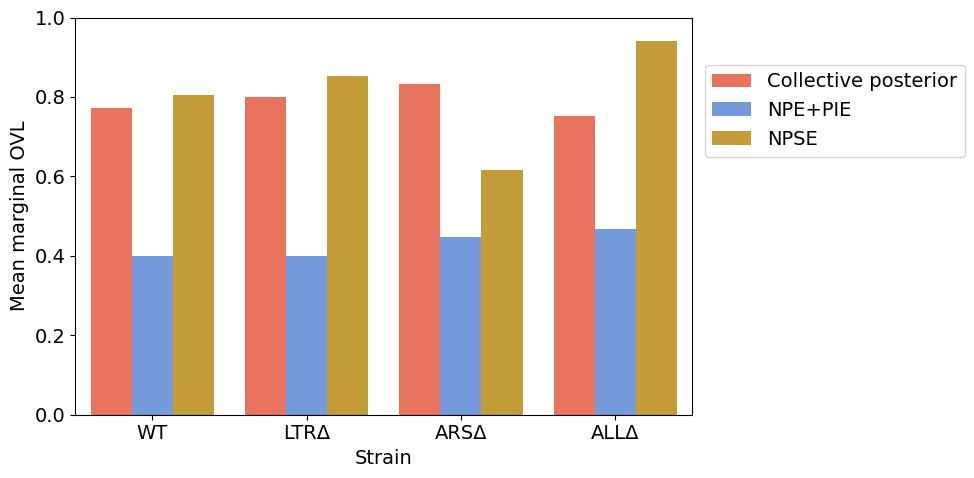

In [6]:
# Distribution overlap: overlapping coefficient + per-parameter KS tests
from scipy.stats import ks_2samp

change_font(14)

PARAM_NAMES = ['s', 'delta', 'p0']
line_dict = {'wt': 'WT', 'ltr': 'LTRΔ', 'ars': 'ARSΔ', 'all': 'ALLΔ'}
method_specs = [
    ('Collective posterior', 'collective_original_samples', 'collective_cycle_samples'),
    ('NPE+PIE', 'npe_pie_original_samples', 'npe_pie_cycle_samples'),
    ('NPSE', 'npse_original_samples', 'npse_cycle_samples'),
]
method_palette = {
    'Collective posterior': 'tomato',
    'NPE+PIE': 'cornflowerblue',
    'NPSE': 'goldenrod',
}

OVERLAP_BINS = 80
KS_TEST_SAMPLES = 2_000
OVERLAP_SEED = 20260430

if 'TESTS_DIR' not in globals():
    TESTS_DIR = Path('tests')
    TESTS_DIR.mkdir(exist_ok=True)
if 'cycle_results' not in globals():
    raise RuntimeError('Run the inference-cycle KDE comparison cell above before computing overlap.')
if 'prior_low' not in globals() or 'prior_high' not in globals():
    if hasattr(prior, 'base_dist') and hasattr(prior.base_dist, 'low'):
        prior_low = prior.base_dist.low.detach().cpu()
        prior_high = prior.base_dist.high.detach().cpu()
    else:
        prior_low = prior.low.detach().cpu()
        prior_high = prior.high.detach().cpu()

required_cycle_keys = [key for _, original_key, cycle_key in method_specs for key in (original_key, cycle_key)]
missing_cycle_keys = [
    f'{line}:{key}'
    for line in lines
    for key in required_cycle_keys
    if line not in cycle_results or key not in cycle_results[line]
]
if missing_cycle_keys:
    raise RuntimeError(
        'Rerun the inference-cycle KDE comparison cell above so cycle_results contains '
        f'the original/cycle sample tensors. Missing keys: {missing_cycle_keys[:5]}'
    )


def to_numpy(samples):
    return torch.as_tensor(samples).detach().cpu().to(torch.float32).numpy()


def balanced_subsample(original, cycle, n_samples, seed):
    rng = np.random.default_rng(seed)
    n = min(n_samples, len(original), len(cycle))
    original_idx = rng.choice(len(original), size=n, replace=False)
    cycle_idx = rng.choice(len(cycle), size=n, replace=False)
    return original[original_idx], cycle[cycle_idx]


def overlapping_coefficient_1d(original, cycle, param_idx, bins=OVERLAP_BINS):
    low = float(prior_low[param_idx])
    high = float(prior_high[param_idx])
    original_counts, _ = np.histogram(original[:, param_idx], bins=bins, range=(low, high))
    cycle_counts, _ = np.histogram(cycle[:, param_idx], bins=bins, range=(low, high))
    original_probs = original_counts / original_counts.sum()
    cycle_probs = cycle_counts / cycle_counts.sum()
    return float(np.minimum(original_probs, cycle_probs).sum())


def overlap_and_ks(original_samples, cycle_samples, seed):
    original = to_numpy(original_samples)
    cycle = to_numpy(cycle_samples)
    original_test, cycle_test = balanced_subsample(original, cycle, KS_TEST_SAMPLES, seed)

    row = {}
    overlaps = []
    ks_stats = []
    ks_ps = []

    for param_idx, param_name in enumerate(PARAM_NAMES):
        ovl = overlapping_coefficient_1d(original, cycle, param_idx)
        ks = ks_2samp(original_test[:, param_idx], cycle_test[:, param_idx], alternative='two-sided', mode='auto')
        overlaps.append(ovl)
        ks_stats.append(float(ks.statistic))
        ks_ps.append(float(ks.pvalue))
        row[f'ovl_{param_name}'] = ovl
        row[f'ks_D_{param_name}'] = float(ks.statistic)
        row[f'ks_p_{param_name}'] = float(ks.pvalue)

    row['mean_ovl'] = float(np.mean(overlaps))
    row['min_ovl'] = float(np.min(overlaps))
    row['mean_ks_D'] = float(np.mean(ks_stats))
    row['min_ks_p'] = float(np.min(ks_ps))
    row['lowest_overlap_param'] = PARAM_NAMES[int(np.argmin(overlaps))]
    return row


overlap_rows = []
for line_idx, line in enumerate(lines):
    for method_idx, (method, original_key, cycle_key) in enumerate(method_specs):
        seed = OVERLAP_SEED + 1_000 * line_idx + 100 * method_idx
        row = {
            'line': line_dict[line],
            'method': method,
            'overlap_index': 'Overlapping coefficient (OVL)',
            'ks_test_samples_per_distribution': min(
                KS_TEST_SAMPLES,
                len(cycle_results[line][original_key]),
                len(cycle_results[line][cycle_key]),
            ),
        }
        row.update(overlap_and_ks(cycle_results[line][original_key], cycle_results[line][cycle_key], seed))
        overlap_rows.append(row)

overlap_df = pd.DataFrame(overlap_rows)
line_order = [line_dict[line] for line in lines]
method_order = [method for method, _, _ in method_specs]
overlap_df['line'] = pd.Categorical(overlap_df['line'], categories=line_order, ordered=True)
overlap_df['method'] = pd.Categorical(overlap_df['method'], categories=method_order, ordered=True)
overlap_df = overlap_df.sort_values(['line', 'method']).reset_index(drop=True)
overlap_df.to_csv(TESTS_DIR / 'cycle_ovl_ks.csv', index=False)
display(overlap_df)

overlap_summary_df = (
    overlap_df
    .groupby('method', as_index=False, sort=False, observed=True)
    .agg(
        median_mean_ovl=('mean_ovl', 'median'),
        median_min_ovl=('min_ovl', 'median'),
        median_mean_ks_D=('mean_ks_D', 'median'),
        min_ks_p=('min_ks_p', 'min'),
    )
)
display(overlap_summary_df)

fig, ax = plt.subplots(1, 1, figsize=(10, 5), tight_layout=True)
sns.barplot(
    data=overlap_df,
    x='line',
    y='mean_ovl',
    hue='method',
    order=line_order,
    hue_order=method_order,
    palette=method_palette,
    ax=ax,
)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean marginal OVL')
ax.set_xlabel('Strain')
ax.legend(title='', loc=(1.02, 0.65))
plt.show()


### Posterior predictive interval coverage

This is a familiar posterior predictive check in observation space. Because the empirical WF datasets do not have known true parameters, this is **not** parameter coverage.

For each dataset and method, draw 200 parameters from the posterior, simulate 200 WF trajectories, and form central posterior predictive intervals at 10%, 20%, ..., 90%, and 95%. Coverage is the fraction of observed empirical replicate-by-generation values that fall inside each interval. A well-calibrated predictive distribution should be close to the diagonal: about 50% of observations inside a 50% interval, about 90% inside a 90% interval, about 95% inside a 95% interval, and so on.


Posterior predictive coverage:   0%|          | 0/12 [00:00<?, ?it/s]

,nominal_coverage,empirical_coverage,mean_generation_coverage,line,method,n_posterior_predictive_draws,n_observed_values,coverage_error,abs_coverage_error
0,0.10,0.083333,0.083333,WT,Collective posterior,200,60,-0.016667,0.016667
1,0.20,0.183333,0.183333,WT,Collective posterior,200,60,-0.016667,0.016667
2,0.30,0.333333,0.333333,WT,Collective posterior,200,60,0.033333,0.033333
3,0.40,0.450000,0.450000,WT,Collective posterior,200,60,0.050000,0.050000
4,0.50,0.533333,0.533333,WT,Collective posterior,200,60,0.033333,0.033333
...,...,...,...,...,...,...,...,...,...
115,0.60,0.114583,0.114583,ALLΔ,NPSE,200,96,-0.485417,0.485417
116,0.70,0.125000,0.125000,ALLΔ,NPSE,200,96,-0.575000,0.575000
117,0.80,0.166667,0.166667,ALLΔ,NPSE,200,96,-0.633333,0.633333
118,0.90,0.229167,0.229167,ALLΔ,NPSE,200,96,-0.670833,0.670833


,line,method,mean_abs_coverage_error
0,WT,Collective posterior,0.090000
1,WT,NPE+PIE,0.328333
2,WT,NPSE,0.415000
3,LTRΔ,Collective posterior,0.056905
4,LTRΔ,NPE+PIE,0.456905
5,LTRΔ,NPSE,0.311667
6,ARSΔ,Collective posterior,0.237857
7,ARSΔ,NPE+PIE,0.327143
8,ARSΔ,NPSE,0.400952
9,ALLΔ,Collective posterior,0.257500


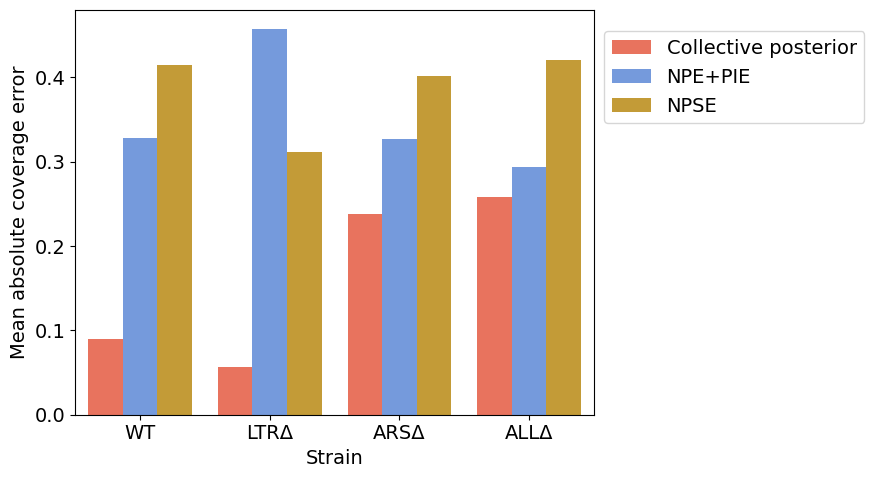

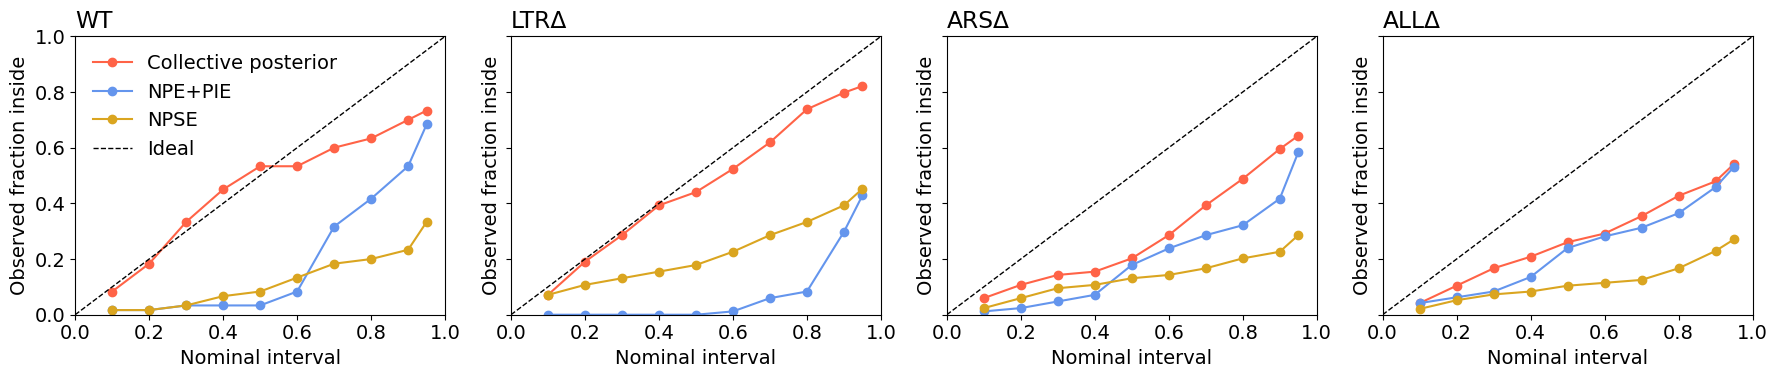

In [7]:
# Posterior predictive interval coverage from 200 posterior-sample simulations
from tqdm.auto import tqdm

change_font(14)

if 'TESTS_DIR' not in globals():
    TESTS_DIR = Path('tests')
    TESTS_DIR.mkdir(exist_ok=True)
if 'posterior_iid' not in globals():
    posterior_iid = pickle.load(open('posteriors/posterior_iid_WF_30000_20.pkl', 'rb'))

PPC_N_DRAWS = 200
PPC_SEED = 20260430
PPC_LEVELS = torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95], dtype=torch.float32)
METHOD_COLORS = {
    'Collective posterior': 'tomato',
    'NPE+PIE': 'cornflowerblue',
    'NPSE': 'goldenrod',
}
line_display = {'wt': 'WT', 'ltr': 'LTRΔ', 'ars': 'ARSΔ', 'all': 'ALLΔ'}


def load_empirical_wf(line):
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0)
    return torch.tensor(np.array(Xs), dtype=torch.float32)


def pad_replicates_for_iid(Xs, max_reps=10):
    full_X = torch.full((max_reps, Xs.shape[1]), torch.nan, dtype=torch.float32)
    full_X[:len(Xs)] = Xs.to(torch.float32)
    return full_X


def load_or_sample_npe_pie_samples(line, n_samples=10_000):
    path = TESTS_DIR / f'samples_npe_pie_{line}.pt'
    saved_samples = try_load_method_samples('npe_pie', line=line)
    if isinstance(saved_samples, torch.Tensor) and saved_samples.shape[0] >= n_samples:
        return saved_samples[:n_samples].detach().cpu()

    if 'cycle_results' in globals() and line in cycle_results and 'npe_pie_original_samples' in cycle_results[line]:
        samples = cycle_results[line]['npe_pie_original_samples'].detach().cpu()
    else:
        Xs = load_empirical_wf(line)
        samples = posterior_iid.set_default_x(pad_replicates_for_iid(Xs)).sample((n_samples,)).detach().cpu()

    torch.save(samples, path)
    return samples


def posterior_samples_for_method(line, method):
    if method == 'Collective posterior':
        if 'collective_posteriors' in globals() and line in collective_posteriors:
            return collective_posteriors[line].samples.detach().cpu()
        return load_collective_samples(line).detach().cpu()
    if method == 'NPE+PIE':
        return load_or_sample_npe_pie_samples(line)
    if method == 'NPSE':
        return load_npse_samples(line).detach().cpu()
    raise ValueError(f'Unknown method: {method}')


def choose_posterior_draws(samples, n_draws, seed):
    samples = torch.as_tensor(samples).detach().cpu().to(torch.float32)
    generator = torch.Generator().manual_seed(seed)
    if samples.shape[0] >= n_draws:
        idx = torch.randperm(samples.shape[0], generator=generator)[:n_draws]
    else:
        idx = torch.randint(samples.shape[0], (n_draws,), generator=generator)
    return samples[idx]


def simulate_wf_draws(theta_draws, seed_offset):
    return torch.stack([
        WF(parameters=theta, seed=seed_offset + draw_idx).to(torch.float32)
        for draw_idx, theta in enumerate(theta_draws)
    ])


def interval_coverage(simulations, observed_xs, levels=PPC_LEVELS):
    observed_xs = observed_xs.to(torch.float32)
    rows = []
    interval_bounds = {}

    for level in levels:
        alpha = float((1.0 - level) / 2.0)
        lower = torch.quantile(simulations, alpha, dim=0)
        upper = torch.quantile(simulations, 1.0 - alpha, dim=0)
        covered = ((observed_xs >= lower) & (observed_xs <= upper)).to(torch.float32)
        interval_bounds[float(level)] = {'lower': lower, 'upper': upper}
        rows.append({
            'nominal_coverage': float(level),
            'empirical_coverage': float(covered.mean()),
            'mean_generation_coverage': float(covered.mean(dim=0).mean()),
        })

    return rows, interval_bounds


ppc_results = {}
coverage_rows = []
coverage_jobs = [(line, method) for line in lines for method in METHOD_COLORS]

for line, method in tqdm(coverage_jobs, desc='Posterior predictive coverage'):
    line_idx = lines.index(line)
    method_idx = list(METHOD_COLORS).index(method)
    seed = PPC_SEED + 1_000 * line_idx + 100 * method_idx

    observed_xs = load_empirical_wf(line)
    posterior_samples = posterior_samples_for_method(line, method)
    theta_draws = choose_posterior_draws(posterior_samples, PPC_N_DRAWS, seed)
    simulations = simulate_wf_draws(theta_draws, seed_offset=seed)
    rows, interval_bounds = interval_coverage(simulations, observed_xs)

    key = f'{method.lower().replace("+", "_").replace(" ", "_")}_{line}'
    ppc_results[key] = {
        'line': line,
        'method': method,
        'theta_draws': theta_draws,
        'simulations': simulations,
        'interval_bounds': interval_bounds,
        'observed_xs': observed_xs,
        'nominal_coverage_levels': PPC_LEVELS,
        'generation': torch.tensor(generation.astype(int), dtype=torch.int64),
    }

    for row in rows:
        row.update({
            'line': line_display[line],
            'method': method,
            'n_posterior_predictive_draws': PPC_N_DRAWS,
            'n_observed_values': int(observed_xs.numel()),
            'coverage_error': row['empirical_coverage'] - row['nominal_coverage'],
            'abs_coverage_error': abs(row['empirical_coverage'] - row['nominal_coverage']),
        })
        coverage_rows.append(row)

torch.save(ppc_results, TESTS_DIR / 'posterior_predictive_interval_coverage_200.pt')
ppc_coverage_df = pd.DataFrame(coverage_rows)
line_order = [line_display[line] for line in lines]
method_order = list(METHOD_COLORS)
ppc_coverage_df['line'] = pd.Categorical(ppc_coverage_df['line'], categories=line_order, ordered=True)
ppc_coverage_df['method'] = pd.Categorical(ppc_coverage_df['method'], categories=method_order, ordered=True)
ppc_coverage_df = ppc_coverage_df.sort_values(['line', 'method', 'nominal_coverage']).reset_index(drop=True)
ppc_coverage_df.to_csv(TESTS_DIR / 'posterior_predictive_interval_coverage_200.csv', index=False)

display(ppc_coverage_df)

coverage_mae_df = (
    ppc_coverage_df
    .groupby(['line', 'method'], as_index=False, sort=False, observed=True)
    .agg(mean_abs_coverage_error=('abs_coverage_error', 'mean'))
)
coverage_mae_df.to_csv(TESTS_DIR / 'posterior_predictive_interval_coverage_mae_200.csv', index=False)
display(coverage_mae_df)

fig, ax_mae = plt.subplots(1, 1, figsize=(9, 5), tight_layout=True)
sns.barplot(
    data=coverage_mae_df,
    x='line',
    y='mean_abs_coverage_error',
    hue='method',
    order=line_order,
    hue_order=method_order,
    palette=METHOD_COLORS,
    ax=ax_mae,
)
ax_mae.set_xlabel('Strain')
ax_mae.set_ylabel('Mean absolute coverage error')
ax_mae.legend(title='', loc=(1.02, 0.72))
plt.show()

fig, axes = plt.subplots(1, len(lines), figsize=(18, 4), sharex=True, sharey=True, tight_layout=True)
for ax, line in zip(axes, lines):
    subset = ppc_coverage_df[ppc_coverage_df['line'] == line_display[line]]
    for method, color in METHOD_COLORS.items():
        method_subset = subset[subset['method'] == method]
        ax.plot(
            method_subset['nominal_coverage'],
            method_subset['empirical_coverage'],
            marker='o',
            color=color,
            label=method,
        )
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.0, label='Ideal' if line == lines[0] else None)
    ax.set_title(line_display[line], loc='left')
    ax.set_xlabel('Nominal interval')
    ax.set_ylabel('Observed fraction inside')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)

axes[0].legend(frameon=False, loc='best')
plt.show()


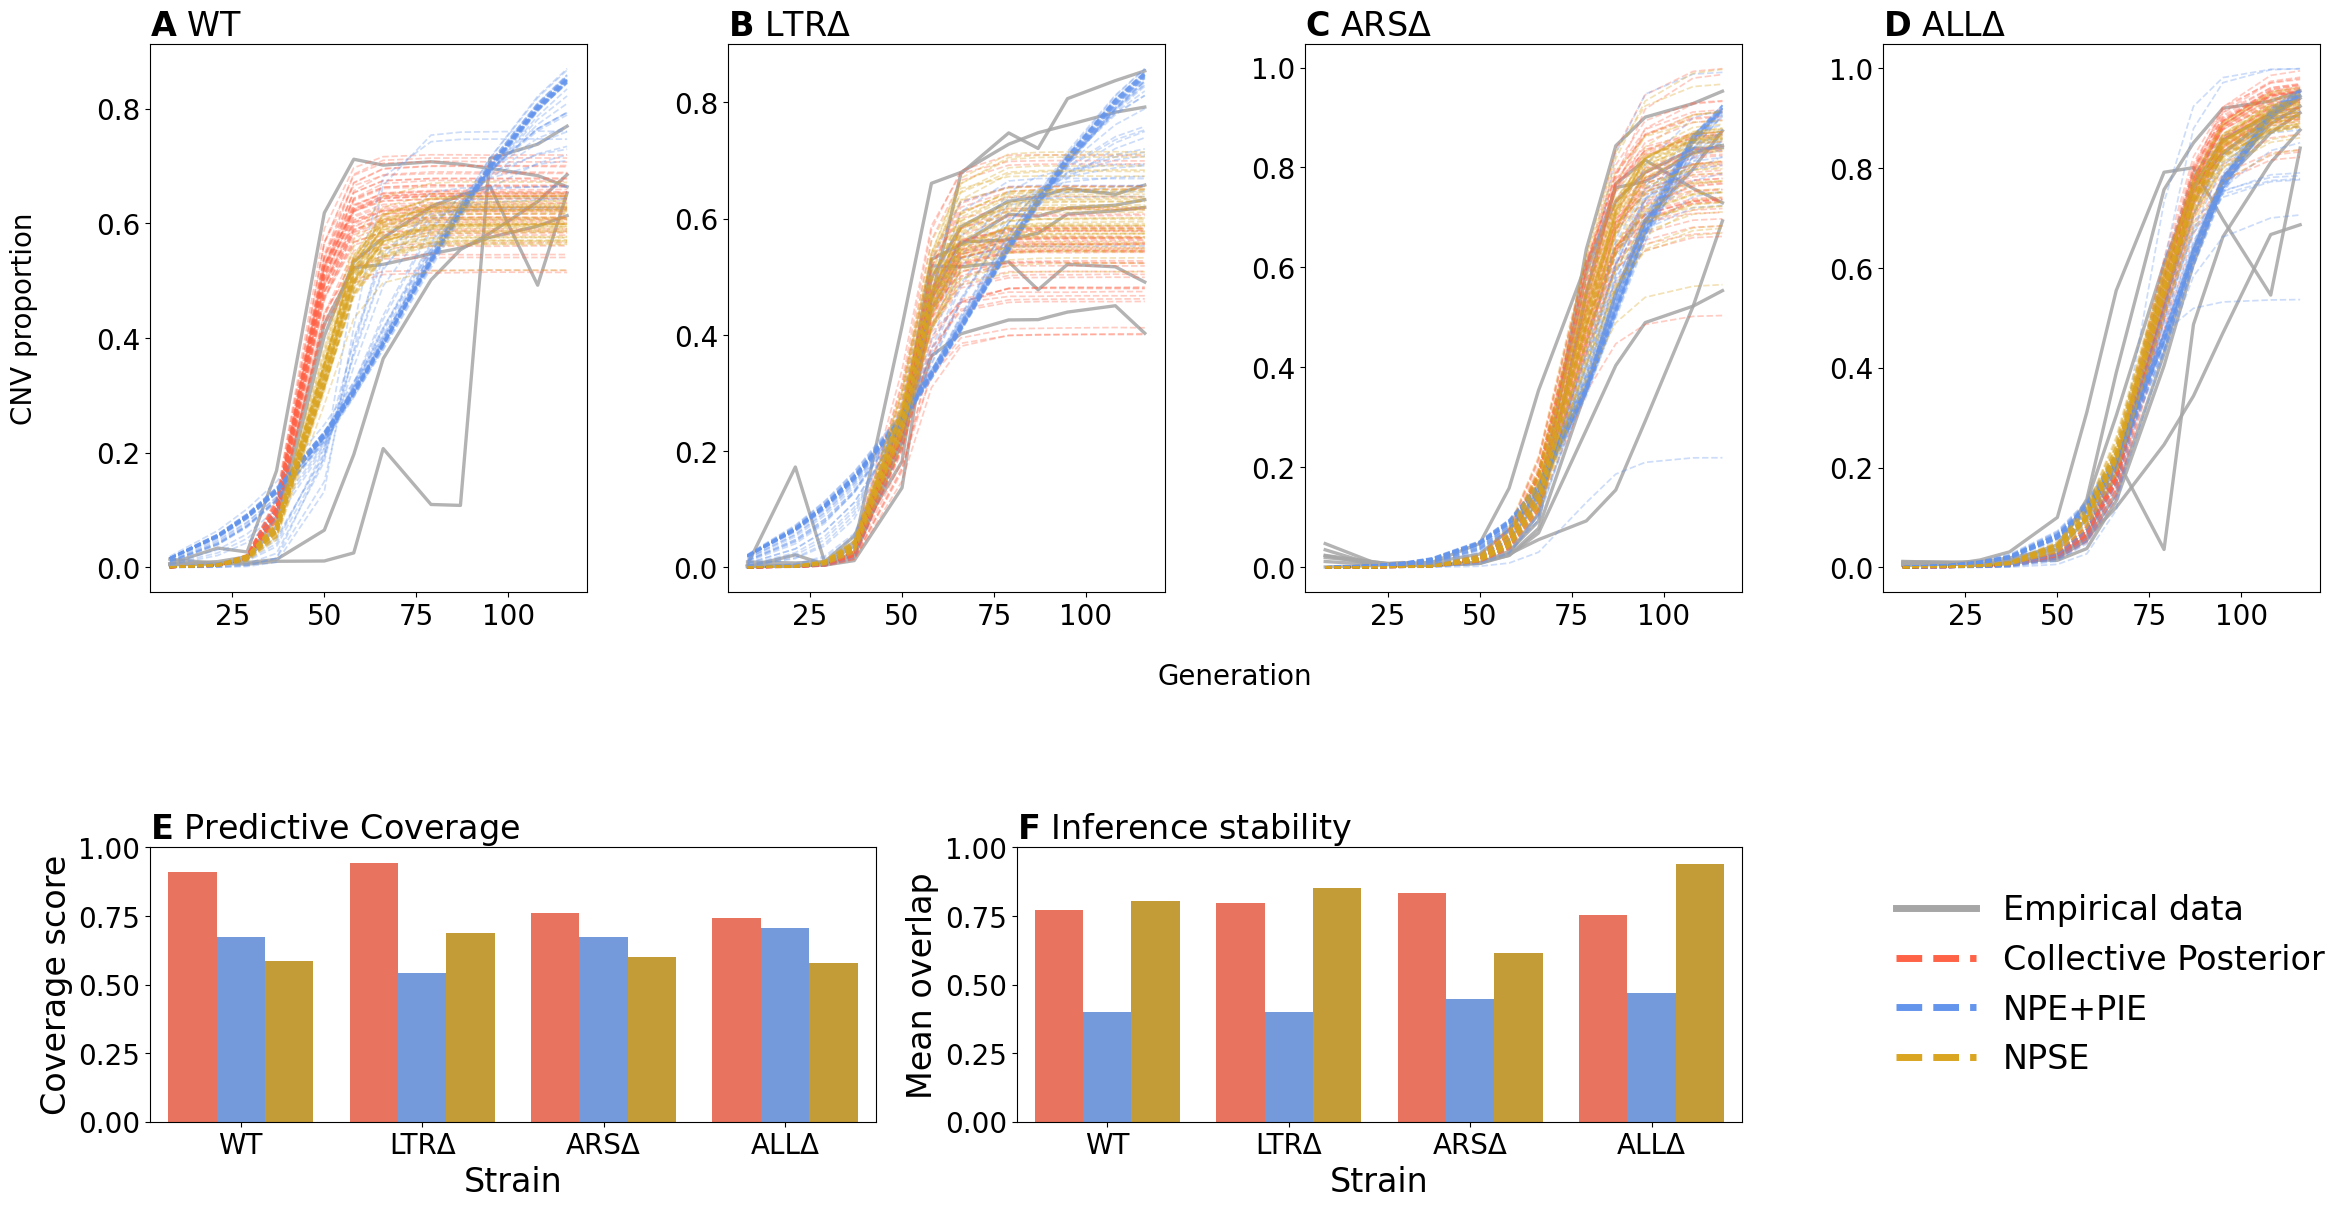

In [8]:
# Combined predictive-check summary figure
change_font(18)

if 'TESTS_DIR' not in globals():
    TESTS_DIR = Path('tests')
TESTS_DIR.mkdir(exist_ok=True)
if 'lines' not in globals():
    lines = ['wt', 'ltr', 'ars', 'all']
if 'generation' not in globals():
    generation = pd.read_csv('empirical_data/Chuong_116_gens.txt').columns

PREDICTIVE_PANEL_N_SAMPLES = 50
PREDICTION_LINEWIDTH = 1.25
PREDICTION_ALPHA = 0.32
EMPIRICAL_LINEWIDTH = 2.4
PREDICTIVE_TITLE_FONTSIZE = 24
PREDICTIVE_AXIS_LABEL_FONTSIZE = 20
PREDICTIVE_TICK_LABEL_FONTSIZE = 20
SUMMARY_TITLE_FONTSIZE = 24
SUMMARY_AXIS_LABEL_FONTSIZE = 24
SUMMARY_TICK_LABEL_FONTSIZE = 20
LEGEND_FONTSIZE = 24
line_display = {'wt': 'WT', 'ltr': 'LTRΔ', 'ars': 'ARSΔ', 'all': 'ALLΔ'}
panel_labels = dict(zip(lines, ['A', 'B', 'C', 'D']))
method_order = ['Collective posterior', 'NPE+PIE', 'NPSE']
method_display_names = {
    'Collective posterior': 'Collective Posterior',
    'NPE+PIE': 'NPE+PIE',
    'NPSE': 'NPSE',
}
method_colors = {
    'Collective posterior': 'tomato',
    'NPE+PIE': 'cornflowerblue',
    'NPSE': 'goldenrod',
}
line_order = [line_display[line] for line in lines]


def load_empirical_wf(line):
    Xs = pd.read_csv(f'empirical_data/{line}.csv', index_col=0)
    return torch.tensor(np.array(Xs), dtype=torch.float32)


def saved_method_samples(method, line):
    if method == 'Collective posterior':
        if 'collective_posteriors' in globals() and line in collective_posteriors:
            return collective_posteriors[line].samples.detach().cpu()
        return load_collective_samples(line).detach().cpu()
    if method == 'NPE+PIE':
        return load_npe_pie_samples(line).detach().cpu()
    if method == 'NPSE':
        return load_npse_samples(line).detach().cpu()
    raise ValueError(f'Unknown method: {method}')


def ordered_summary(df, value_columns):
    df = df.copy()
    df['line'] = pd.Categorical(df['line'], categories=line_order, ordered=True)
    df['method'] = pd.Categorical(df['method'], categories=method_order, ordered=True)
    return df.sort_values(['line', 'method', *value_columns]).reset_index(drop=True)


def load_coverage_mae_df():
    if 'coverage_mae_df' in globals():
        df = coverage_mae_df.copy()
    else:
        path = TESTS_DIR / 'posterior_predictive_interval_coverage_mae_200.csv'
        if not path.exists():
            raise FileNotFoundError(f'Missing {path}. Run the posterior predictive interval coverage cell first.')
        df = pd.read_csv(path)
    return ordered_summary(df, [])


def load_overlap_df():
    if 'overlap_df' in globals():
        df = overlap_df.copy()
    else:
        path = TESTS_DIR / 'cycle_ovl_ks.csv'
        if not path.exists():
            raise FileNotFoundError(f'Missing {path}. Run the distribution overlap cell first.')
        df = pd.read_csv(path)
    return ordered_summary(df, [])


def plot_predictive_panel(ax, line):
    Xs = load_empirical_wf(line)
    gens = generation.astype(int)

    for obs_idx, x in enumerate(Xs):
        ax.plot(
            gens,
            x,
            color='0.65',
            lw=EMPIRICAL_LINEWIDTH,
            alpha=0.85,
            label='Empirical data' if obs_idx == 0 else None,
        )

    for method in method_order:
        samples = saved_method_samples(method, line)[:PREDICTIVE_PANEL_N_SAMPLES]
        for sample_idx, theta in enumerate(samples):
            ax.plot(
                gens,
                WF(parameters=theta).cpu(),
                color=method_colors[method],
                ls='--',
                lw=PREDICTION_LINEWIDTH,
                alpha=PREDICTION_ALPHA,
                label=method_display_names[method] if sample_idx == 0 else None,
            )

    ax.set_title(fr'$\bf{{{panel_labels[line]}}}$ {line_display[line]}', loc='left', fontsize=PREDICTIVE_TITLE_FONTSIZE)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=PREDICTIVE_TICK_LABEL_FONTSIZE)


coverage_mae_plot_df = load_coverage_mae_df()
coverage_score_plot_df = coverage_mae_plot_df.copy()
coverage_score_plot_df['coverage_agreement'] = (1.0 - coverage_score_plot_df['mean_abs_coverage_error']).clip(0.0, 1.0)
overlap_plot_df = load_overlap_df()

fig, ax = plt.subplot_mosaic(
    '''
    AABBCCDD
    EEEFFFGG
    ''',
    figsize=(28, 14),
    gridspec_kw={'height_ratios': [2.3, 1.15], 'hspace': 0.62, 'wspace': 0.95},
    constrained_layout=False,
)

for line in lines:
    plot_predictive_panel(ax[panel_labels[line]], line)

top_row_boxes = [ax[panel_labels[line]].get_position() for line in lines]
top_row_left = min(box.x0 for box in top_row_boxes)
top_row_right = max(box.x1 for box in top_row_boxes)
top_row_bottom = min(box.y0 for box in top_row_boxes)
top_row_top = max(box.y1 for box in top_row_boxes)
fig.text(
    (top_row_left + top_row_right) / 2,
    top_row_bottom - 0.06,
    'Generation',
    ha='center',
    va='center',
    fontsize=PREDICTIVE_AXIS_LABEL_FONTSIZE,
)
fig.text(
    top_row_left - 0.045,
    (top_row_bottom + top_row_top) / 2,
    'CNV proportion',
    ha='center',
    va='center',
    rotation='vertical',
    fontsize=PREDICTIVE_AXIS_LABEL_FONTSIZE,
)

predictive_handles = [
    plt.Line2D([0], [0], color='0.65', lw=5.0, label='Empirical data'),
    *[
        plt.Line2D([0], [0], color=method_colors[method], lw=5.0, ls='--', label=method_display_names[method])
        for method in method_order
    ],
]
sns.barplot(
    data=coverage_score_plot_df,
    x='line',
    y='coverage_agreement',
    hue='method',
    order=line_order,
    hue_order=method_order,
    palette=method_colors,
    ax=ax['E'],
)
ax['E'].set_title(r'$\bf{E}$ Predictive Coverage', loc='left', fontsize=SUMMARY_TITLE_FONTSIZE)
ax['E'].set_xlabel('Strain', fontsize=SUMMARY_AXIS_LABEL_FONTSIZE)
ax['E'].set_ylabel('Coverage score', fontsize=SUMMARY_AXIS_LABEL_FONTSIZE)
ax['E'].set_ylim(0, 1)
ax['E'].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax['E'].set_xlim(-0.5, len(line_order) - 0.5)
ax['E'].tick_params(axis='both', labelsize=SUMMARY_TICK_LABEL_FONTSIZE)
if ax['E'].legend_ is not None:
    ax['E'].legend_.remove()

sns.barplot(
    data=overlap_plot_df,
    x='line',
    y='mean_ovl',
    hue='method',
    order=line_order,
    hue_order=method_order,
    palette=method_colors,
    ax=ax['F'],
)
ax['F'].set_title(r'$\bf{F}$ Inference stability', loc='left', fontsize=SUMMARY_TITLE_FONTSIZE)
ax['F'].set_xlabel('Strain', fontsize=SUMMARY_AXIS_LABEL_FONTSIZE)
ax['F'].set_ylabel('Mean overlap', fontsize=SUMMARY_AXIS_LABEL_FONTSIZE)
ax['F'].set_ylim(0, 1)
ax['F'].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax['F'].tick_params(axis='both', labelsize=SUMMARY_TICK_LABEL_FONTSIZE)
if ax['F'].legend_ is not None:
    ax['F'].legend_.remove()

ax['G'].axis('off')
ax['G'].legend(
    handles=predictive_handles,
    title='',
    frameon=False,
    loc='center left',
    fontsize=LEGEND_FONTSIZE,
    handlelength=2.4,
    borderaxespad=0.0,
)

fig.savefig(TESTS_DIR / 'predictive_checks_summary.png', dpi=400, bbox_inches='tight')
fig.savefig(TESTS_DIR / 'predictive_checks_summary.tif', dpi=400, bbox_inches='tight')
fig.savefig(TESTS_DIR / 'predictive_checks_summary.pdf', dpi=400, bbox_inches='tight')
plt.show()


## LTR Predictive Check And Coverage

This figure isolates the `LTRΔ` dataset. The top panel shows posterior predictive checks for `Collective posterior`, `NPE+PIE`, and `NPSE`; the bottom panel shows the posterior predictive interval coverage curve for the same line.


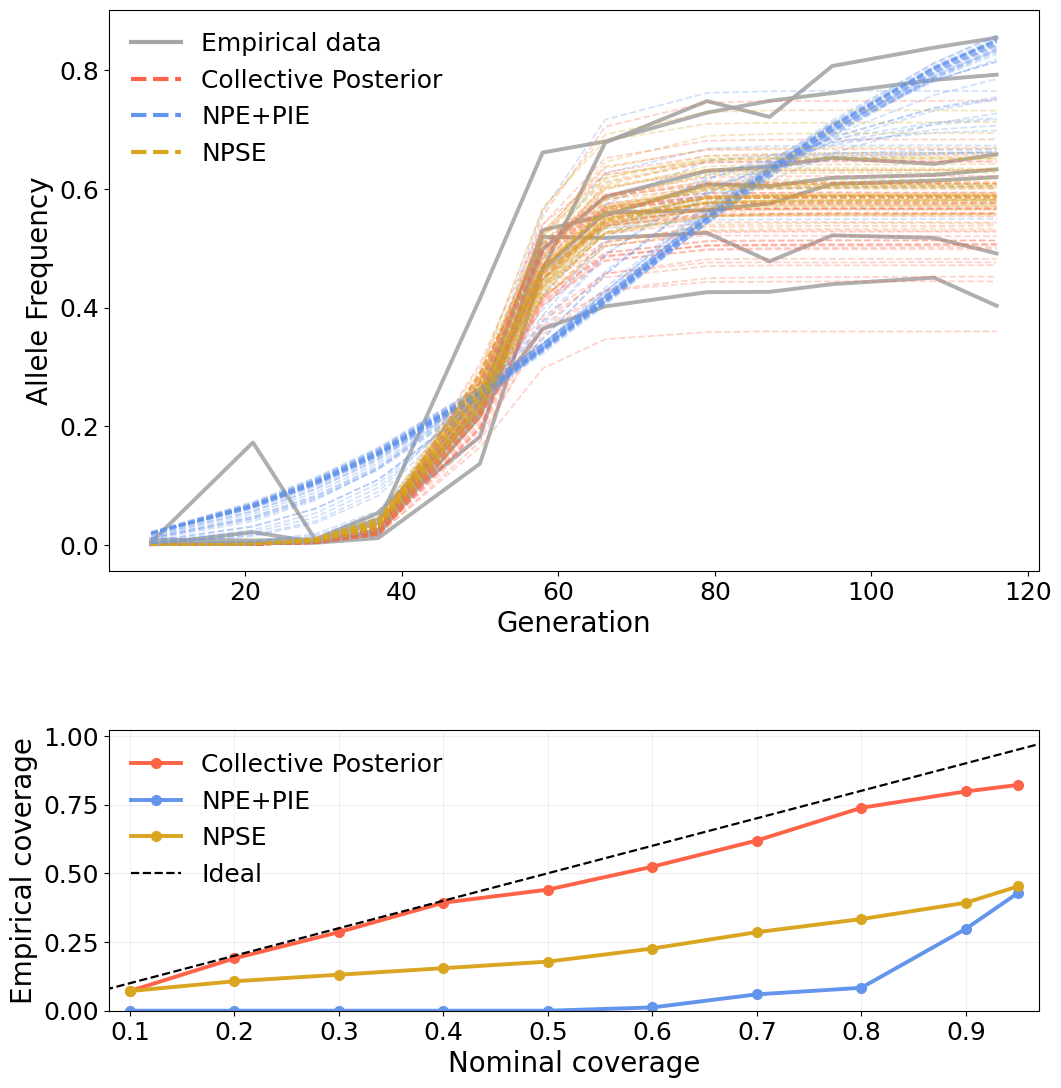

In [9]:
# LTR-only predictive checks + coverage curve
change_font(20)

if 'ppc_results' not in globals():
    raise RuntimeError('Run the posterior predictive interval coverage cell first so ppc_results is available.')
if 'coverage_mae_df' not in globals():
    coverage_csv = TESTS_DIR / 'posterior_predictive_interval_coverage_mae_200.csv'
    if not coverage_csv.exists():
        raise FileNotFoundError(f'Missing {coverage_csv}. Run the posterior predictive interval coverage cell first.')
    coverage_mae_df = pd.read_csv(coverage_csv)

LTR_METHODS = ['Collective posterior', 'NPE+PIE', 'NPSE']
LTR_COLORS = {
    'Collective posterior': 'tomato',
    'NPE+PIE': 'cornflowerblue',
    'NPSE': 'goldenrod',
}
LTR_DISPLAY = {
    'Collective posterior': 'Collective Posterior',
    'NPE+PIE': 'NPE+PIE',
    'NPSE': 'NPSE',
}
LTR_KEY = {
    'Collective posterior': 'collective_posterior_ltr',
    'NPE+PIE': 'npe_pie_ltr',
    'NPSE': 'npse_ltr',
}
LTR_N_PPC = 50
EMP_LW = 2.8
PRED_LW = 1.3
PRED_ALPHA = 0.28
LINE_TITLE_FONTSIZE = 24
LINE_AXIS_FONTSIZE = 20
LINE_TICK_FONTSIZE = 18
LEGEND_FONTSIZE = 18

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 13),
    gridspec_kw={'height_ratios': [2.2, 1.1], 'hspace': 0.38},
    tight_layout=False,
)
ax_ppc, ax_cov = axes

Xs_ltr = load_empirical_wf('ltr')
gens = generation.astype(int)
for obs_idx, x in enumerate(Xs_ltr):
    ax_ppc.plot(
        gens,
        x,
        color='0.65',
        lw=EMP_LW,
        alpha=0.9,
        label='Empirical data' if obs_idx == 0 else None,
    )

for method in LTR_METHODS:
    samples = posterior_samples_for_method('ltr', method)[:LTR_N_PPC]
    for sample_idx, theta in enumerate(samples):
        ax_ppc.plot(
            gens,
            WF(parameters=theta).cpu(),
            color=LTR_COLORS[method],
            ls='--',
            lw=PRED_LW,
            alpha=PRED_ALPHA,
            label=LTR_DISPLAY[method] if sample_idx == 0 else None,
        )

ax_ppc.set_xlabel('Generation', fontsize=LINE_AXIS_FONTSIZE)
ax_ppc.set_ylabel('Allele Frequency', fontsize=LINE_AXIS_FONTSIZE)
ax_ppc.tick_params(axis='both', labelsize=LINE_TICK_FONTSIZE)
leg = ax_ppc.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper left')
for handle in leg.legendHandles:
    handle.set_alpha(1.0)
    handle.set_linewidth(3.0)

for method in LTR_METHODS:
    key = LTR_KEY[method]
    result = ppc_results[key]
    nominal = torch.as_tensor(result['nominal_coverage_levels']).cpu().numpy()
    empirical = []
    for level in nominal:
        level_key = float(level)
        lower = result['interval_bounds'][level_key]['lower']
        upper = result['interval_bounds'][level_key]['upper']
        covered = ((result['observed_xs'] >= lower) & (result['observed_xs'] <= upper)).to(torch.float32)
        empirical.append(float(covered.mean()))
    ax_cov.plot(
        nominal,
        empirical,
        color=LTR_COLORS[method],
        marker='o',
        lw=2.8,
        ms=7,
        label=LTR_DISPLAY[method],
    )

ax_cov.plot([0, 1], [0, 1], color='black', ls='--', lw=1.6, label='Ideal')
ax_cov.set_xlabel('Nominal coverage', fontsize=LINE_AXIS_FONTSIZE)
ax_cov.set_ylabel('Empirical coverage', fontsize=LINE_AXIS_FONTSIZE)
ax_cov.tick_params(axis='both', labelsize=LINE_TICK_FONTSIZE)
ax_cov.legend(frameon=False, fontsize=LEGEND_FONTSIZE, loc='upper left')
ax_cov.set_xlim(0.08, 0.97)
ax_cov.set_ylim(0.0, 1.02)
ax_cov.grid(alpha=0.2)

plt.show()




Text(0, 0.5, 'Allele Frequency')

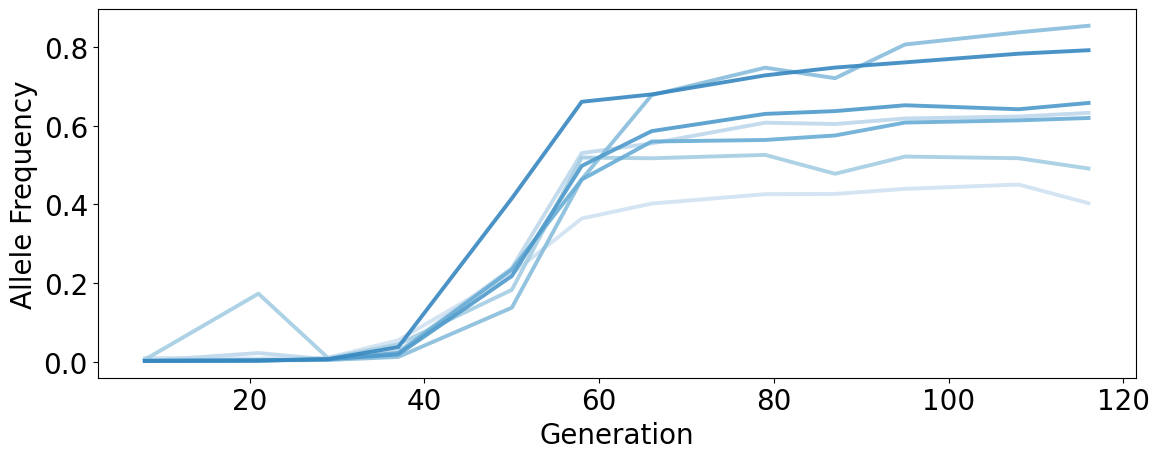

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5), tight_layout=True)
cmap = plt.get_cmap('Blues')
Xs_ltr = load_empirical_wf('ltr')
gens = generation.astype(int)
for obs_idx, x in enumerate(Xs_ltr):
    ax.plot(
        gens,
        x,
        lw=EMP_LW,
        color=cmap(obs_idx * 20 + 50),
        alpha=0.9,
        label='Empirical data' if obs_idx == 0 else None,
    )

plt.xlabel('Generation', fontsize=LINE_AXIS_FONTSIZE)
plt.ylabel('Allele Frequency', fontsize=LINE_AXIS_FONTSIZE)